# Associative Memories via Predictive Coding

Reproduces experiments from:
> Salvatori et al. (2021) **"Associative Memories via Predictive Coding"** &mdash; [arXiv:2109.08063](https://arxiv.org/abs/2109.08063)

Uses **FabricPC** (JAX predictive coding framework) to demonstrate that generative predictive coding networks store training data as *attractors*, enabling retrieval from corrupted or partial observations.

## Architecture (generative PCN, top-down)

```
memory(n) --> hidden_{L-1}(n) --> ... --> hidden_0(n) --> sensory(d)
(IdentityNode)   (PreSynapticLinear)      (PreSynapticLinear) (PreSynapticLinear, clamped)
```

During training the **sensory** layer is clamped to the target image. The **memory** node (`in_degree=0`, unclamped) and all hidden layers evolve freely under the inference dynamics, then weights are updated to minimise the prediction-error energy. After training, each stored image becomes an attractor of the network dynamics.

### Pre-synaptic activation (paper-faithful)

The paper applies activations *pre-synaptically*: `mu^l = theta^{l+1} f(x^{l+1})`, where `f` (ReLU) is applied to the **source** node's latent *before* the weight multiplication. This is implemented via a custom `PreSynapticLinear` node: `z_mu = W @ f(x) + b`.

### Experiments

| # | Experiment | Paper Section |
|---|-----------|---------------|
| 1 | **Denoising** &mdash; retrieve stored CIFAR-10 images from Gaussian-corrupted versions | Section 3 |
| 2 | **Partial Retrieval** &mdash; reconstruct images given only a fraction of known pixels | Section 4 |
| 3 | **Deep PCNs** &mdash; increase network depth to improve retrieval capacity | Section 5.1 |

## 0. Imports & Setup

In [ ]:
import time
import numpy as np
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt

from fabricpc.nodes import IdentityNode, Linear
from fabricpc.nodes.base import NodeBase, SlotSpec, FlattenInputMixin
from fabricpc.core.topology import Edge
from fabricpc.graph_assembly import TaskMap, graph
from fabricpc.graph_initialization import initialize_params
from fabricpc.graph_initialization.state_initializer import initialize_graph_state
from fabricpc.core.inference import InferenceSGD, run_inference
from fabricpc.core.activations import ReLUActivation, IdentityActivation
from fabricpc.core.energy import GaussianEnergy
from fabricpc.core.initializers import KaimingInitializer, NormalInitializer, initialize
from fabricpc.core.state_ops import update_node_in_state
from fabricpc.core.types import NodeParams, NodeState, NodeInfo
from fabricpc.training import train_pcn
from fabricpc import setup_jax

setup_jax()
jax.config.update("jax_default_prng_impl", "threefry2x32")

SEED = 42
print(f"JAX devices: {jax.devices()}")

## 1. Data Loading

Load a random subset of CIFAR-10 training images, flattened to vectors and normalised to [0, 1].

In [19]:
def load_cifar10_subset(num_images, seed=42):
    """Load a random subset of CIFAR-10 training images.

    Returns
    -------
    images : ndarray, shape (num_images, 3072), dtype float32, values in [0, 1]
    """
    import tensorflow_datasets as tfds
    import tensorflow as tf
    tf.config.set_visible_devices([], "GPU")

    ds = tfds.load("cifar10", split="train", as_supervised=True)
    all_images = []
    for img, _label in ds:
        all_images.append(img.numpy().astype(np.float32) / 255.0)
        if len(all_images) >= max(num_images * 3, 1000):
            break

    all_images = np.stack(all_images, axis=0)
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(all_images), num_images, replace=False)
    images = all_images[indices]
    return images.reshape(num_images, -1)  # (N, 3072)

## 2. Memorisation Data Loader

Wraps the image array so FabricPC's `train_pcn` can iterate over it. For small memorisation datasets the entire set fits in a single batch.

In [20]:
class MemorizationLoader:
    """Yields the memorisation dataset in batches (shuffled each epoch)."""

    def __init__(self, images, batch_size=None, seed=42):
        self.images = np.asarray(images, dtype=np.float32)
        self.batch_size = batch_size or len(images)
        self.seed = seed
        self._epoch = 0
        self.num_samples = len(images)
        self._num_batches = max(1, self.num_samples // self.batch_size)

    def __iter__(self):
        rng = np.random.default_rng(
            self.seed + self._epoch if self.seed is not None else None
        )
        self._epoch += 1
        indices = rng.permutation(self.num_samples)
        for start in range(0, self.num_samples - self.batch_size + 1, self.batch_size):
            batch_idx = indices[start : start + self.batch_size]
            yield {"x": self.images[batch_idx]}

    def __len__(self):
        return self._num_batches

## 2b. Pre-Synaptic Linear Node

The paper computes predictions as `mu^l = W^{l+1} @ f(x^{l+1})` where `f` (ReLU) is applied to the **source** node's latent *before* the weight multiplication. FabricPC's `Linear` node applies activation *post-synaptically*: `z_mu = f(W @ x + b)`.

This custom `PreSynapticLinear` node implements the paper's formulation exactly: `z_mu = W @ f(x) + b`.

In [ ]:
class PreSynapticLinear(FlattenInputMixin, NodeBase):
    """Linear node with pre-synaptic activation: z_mu = W @ f(x) + b

    Matches the paper's formulation: mu^l = theta^{l+1} @ f(x^{l+1}).
    The activation f (e.g. ReLU) is applied to the input (source latent)
    BEFORE the weight multiplication.
    """

    def __init__(self, shape, name, input_activation=ReLUActivation(),
                 energy=GaussianEnergy(), use_bias=True, flatten_input=True,
                 weight_init=KaimingInitializer(), latent_init=NormalInitializer()):
        super().__init__(
            shape=shape, name=name,
            activation=IdentityActivation(),  # no post-synaptic activation
            energy=energy, latent_init=latent_init, weight_init=weight_init,
            use_bias=use_bias, flatten_input=flatten_input,
            input_activation=input_activation,  # stored in node_config
        )

    @staticmethod
    def get_slots():
        return {"in": SlotSpec(name="in", is_multi_input=True)}

    @staticmethod
    def initialize_params(key, node_shape, input_shapes, weight_init, config=None):
        if config is None:
            config = {}
        flatten_input = config.get("flatten_input", False)
        key_w, key_b = jax.random.split(key)
        weights_dict = {}
        rand_key_w = dict(
            zip(input_shapes.keys(), jax.random.split(key_w, len(input_shapes))))
        for edge_key, in_shape in input_shapes.items():
            if flatten_input:
                in_numel = int(np.prod(in_shape))
                out_numel = int(np.prod(node_shape))
                weight_shape = (in_numel, out_numel)
            else:
                weight_shape = (in_shape[-1], node_shape[-1])
            weights_dict[edge_key] = initialize(
                rand_key_w[edge_key], weight_shape, weight_init)
        use_bias = config.get("use_bias", True)
        biases = {}
        if use_bias:
            bias_shape = (1,) * len(node_shape) + (node_shape[-1],)
            biases["b"] = jnp.zeros(bias_shape)
        return NodeParams(weights=weights_dict, biases=biases)

    @staticmethod
    def forward(params, inputs, state, node_info):
        """z_mu = W @ f(x) + b  (pre-synaptic activation)."""
        batch_size = state.z_latent.shape[0]
        out_shape = node_info.shape
        flatten_input = node_info.node_config.get("flatten_input", False)
        input_act = node_info.node_config["input_activation"]

        # Apply pre-synaptic activation to all inputs
        activated = {}
        for edge_key, x in inputs.items():
            activated[edge_key] = type(input_act).forward(x, input_act.config)

        # Linear transformation on activated inputs
        if flatten_input:
            z_mu = FlattenInputMixin.compute_linear(
                activated, params.weights, batch_size, out_shape)
        else:
            z_mu = jnp.zeros((batch_size,) + out_shape)
            for edge_key, x in activated.items():
                z_mu = z_mu + jnp.matmul(x, params.weights[edge_key])

        if "b" in params.biases and params.biases["b"].size > 0:
            z_mu = z_mu + params.biases["b"]

        error = state.z_latent - z_mu
        state = state._replace(z_mu=z_mu, error=error)
        node_class = node_info.node_class
        state = node_class.energy_functional(state, node_info)
        return state

## 3. Graph Construction

Build a **generative PCN** for associative memory. The top-down chain goes:

```
memory(n)  -->  hidden_{L-1}(n)  -->  ...  -->  hidden_0(n)  -->  sensory(d)
```

- **memory** &mdash; `IdentityNode`, `in_degree=0`. Its `z_latent` evolves during inference via error gradients from downstream.
- **hidden** layers &mdash; `PreSynapticLinear` with ReLU applied to the source latent before matmul.
- **sensory** &mdash; `PreSynapticLinear` (ReLU on input from hidden_0), clamped to data during training.

In [ ]:
def build_generative_pcn(data_dim, hidden_dim, num_hidden_layers=1,
                         infer_steps=24, eta_infer=0.1):
    """Build a generative PCN for associative memory.

    Uses PreSynapticLinear nodes: z_mu = W @ ReLU(x) + b,
    matching the paper's formulation.
    """
    memory = IdentityNode(shape=(hidden_dim,), name="memory")

    hidden_layers = [
        PreSynapticLinear(shape=(hidden_dim,), name=f"hidden_{i}",
                          input_activation=ReLUActivation(),
                          weight_init=KaimingInitializer(),
                          flatten_input=True, use_bias=True)
        for i in range(num_hidden_layers)
    ]

    sensory = PreSynapticLinear(shape=(data_dim,), name="sensory",
                                input_activation=ReLUActivation(),
                                weight_init=KaimingInitializer(),
                                flatten_input=True, use_bias=True)

    nodes = [memory] + hidden_layers + [sensory]
    edges = [Edge(source=nodes[i], target=nodes[i + 1].slot("in"))
             for i in range(len(nodes) - 1)]

    return graph(nodes=nodes, edges=edges,
                 task_map=TaskMap(x=sensory),
                 inference=InferenceSGD(eta_infer=eta_infer, infer_steps=infer_steps))

## 4. Training

Train the generative PCN to *memorise* a set of images. The energy should converge to near zero, meaning the model has learned to perfectly reconstruct every stored image.

In [ ]:
def train_generative_pcn(images, hidden_dim, num_hidden_layers=1,
                         num_epochs=2000, lr=0.001, infer_steps=24,
                         eta_infer=0.1, batch_size=None, seed=42, verbose=True):
    """Train a generative PCN to memorise images (normalised to [0,1]).

    Returns (trained_params, structure, energy_history).
    """
    data_dim = images.shape[1]
    structure = build_generative_pcn(data_dim, hidden_dim, num_hidden_layers,
                                     infer_steps, eta_infer)

    rng_key = jax.random.PRNGKey(seed)
    rng_key, init_key = jax.random.split(rng_key)
    params = initialize_params(structure, init_key)

    n_params = sum(p.size for p in jax.tree_util.tree_leaves(params))
    if verbose:
        arch = " -> ".join(
            [f"memory({hidden_dim})"]
            + [f"hidden_{i}({hidden_dim})" for i in range(num_hidden_layers)]
            + [f"sensory({data_dim})"]
        )
        print(f"Architecture: {arch}")
        print(f"Parameters:   {n_params:,}")

    optimizer = optax.adam(lr)
    loader = MemorizationLoader(images, batch_size=batch_size, seed=seed)
    rng_key, train_key = jax.random.split(rng_key)

    trained_params, energy_history, _ = train_pcn(
        params=params, structure=structure,
        train_loader=loader, optimizer=optimizer,
        config={"num_epochs": num_epochs},
        rng_key=train_key, verbose=verbose,
    )
    return trained_params, structure, energy_history

## 5. Retrieval Functions

### 5a. Denoising &mdash; Iterative retrieval function *F* (Section 3, Figure 2)

1. Clamp sensory to the current (corrupted) estimate
2. Run inference for *T* steps
3. Read the sensory-layer **prediction** $\mu^0_T$ as the new estimate
4. Repeat for *M* iterations

In [ ]:
def retrieve_from_corruption(params, structure, corrupted_images,
                             num_iterations=30, retrieval_infer_steps=200,
                             retrieval_eta_infer=0.01, seed=42):
    """Iterative retrieval function F from corrupted images.

    retrieval_eta_infer defaults to 0.01 (lower than training) to keep
    the dynamics stable when starting far from an attractor.
    """
    sensory_name = structure.task_map["x"]
    inference_obj = structure.config["inference"]
    inference_cls = type(inference_obj)
    base_config = dict(inference_obj.config)
    base_config["infer_steps"] = retrieval_infer_steps
    base_config["eta_infer"] = retrieval_eta_infer

    batch_size = corrupted_images.shape[0]
    current = jnp.array(corrupted_images)
    rng_key = jax.random.PRNGKey(seed)

    for m in range(num_iterations):
        rng_key, step_key = jax.random.split(rng_key)
        clamps = {sensory_name: current}
        state = initialize_graph_state(structure, batch_size, step_key,
                                       clamps=clamps, params=params)

        def _body(t, s):
            return inference_cls.inference_step(params, s, clamps, structure,
                                                base_config)

        final_state = jax.lax.fori_loop(0, retrieval_infer_steps, _body, state)
        current = final_state.nodes[sensory_name].z_mu
        # Clip to prevent runaway values between F iterations
        current = jnp.clip(current, -1.0, 2.0)

    return np.asarray(current)

### 5b. Partial Image Retrieval (Section 4, Algorithm 2)

Known pixels (where `mask == True`) are **pinned** after every inference step; unknown pixels evolve freely under the energy dynamics until the model fills them in.

In [ ]:
def retrieve_from_partial(params, structure, images, mask,
                          infer_steps=500, retrieval_eta_infer=0.01, seed=42):
    """Retrieve complete images from partial observations."""
    sensory_name = structure.task_map["x"]
    inference_obj = structure.config["inference"]
    inference_cls = type(inference_obj)
    config = dict(inference_obj.config)
    config["infer_steps"] = infer_steps
    config["eta_infer"] = retrieval_eta_infer

    batch_size = images.shape[0]
    rng_key = jax.random.PRNGKey(seed)

    # Sensory is NOT clamped -- it is free to update,
    # but we re-pin the known pixels after every step.
    clamps = {}
    state = initialize_graph_state(structure, batch_size, rng_key,
                                   clamps=clamps, params=params)

    images_jnp = jnp.array(images)
    mask_jnp = jnp.array(mask)
    z_init = jnp.where(mask_jnp, images_jnp,
                       state.nodes[sensory_name].z_latent)
    state = update_node_in_state(state, sensory_name, z_latent=z_init)

    def _body(t, s):
        s = inference_cls.inference_step(params, s, clamps, structure, config)
        z = s.nodes[sensory_name].z_latent
        z = jnp.where(mask_jnp, images_jnp, z)     # re-pin known pixels
        s = update_node_in_state(s, sensory_name, z_latent=z)
        return s

    final_state = jax.lax.fori_loop(0, infer_steps, _body, state)
    return np.asarray(final_state.nodes[sensory_name].z_latent)

## 6. Utilities &mdash; Noise, Masks, Metrics, Visualisation

In [ ]:
def add_gaussian_noise(images, variance=0.2, seed=42):
    """Corrupt images with additive Gaussian noise (paper default: variance=0.2)."""
    rng = np.random.default_rng(seed)
    noise = rng.normal(0, np.sqrt(variance), images.shape).astype(np.float32)
    return images + noise


def generate_pixel_mask(num_images, data_dim, fraction, seed=42):
    """Random pixel mask -- each pixel kept independently with prob `fraction`."""
    rng = np.random.default_rng(seed)
    return rng.random((num_images, data_dim)) < fraction


def retrieval_metrics(original, retrieved, threshold=0.005):
    """Per-image MSE and fraction correctly retrieved (MSE < threshold)."""
    per_img = np.mean((original - retrieved) ** 2, axis=1)
    return {
        "accuracy": float(np.mean(per_img < threshold)),
        "mean_mse": float(np.mean(per_img)),
        "max_mse": float(np.max(per_img)),
        "per_image_mse": per_img,
    }


def show_reconstruction_grid(original, input_imgs, retrieved, title="",
                              ncols=10, img_shape=(32, 32, 3)):
    """Display a 3-row grid: original / input / retrieved."""
    n = min(len(original), ncols)
    fig, axes = plt.subplots(3, n, figsize=(2 * n, 6.5))
    if n == 1:
        axes = axes[:, None]
    row_labels = ["Original", "Input", "Retrieved"]
    for row_idx, imgs in enumerate([original, input_imgs, retrieved]):
        for col in range(n):
            img = np.nan_to_num(imgs[col], nan=0.5).reshape(img_shape).clip(0, 1)
            axes[row_idx, col].imshow(img)
            axes[row_idx, col].axis("off")
        axes[row_idx, 0].set_ylabel(row_labels[row_idx], fontsize=11)
    if title:
        fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

---

## Experiment 1 &mdash; Denoising (Section 3)

**Protocol:** Train a 2-layer generative PCN on *N* CIFAR-10 images. Corrupt the stored images with Gaussian noise (variance 0.2). Retrieve the originals by iterating the function *F* (clamp corrupted image, run inference, read prediction).

Paper hyperparameters (Appendix B):
- Inference steps *T* (training): 12--32 &nbsp;|&nbsp; *T* (retrieval): 100--500
- Inference LR $\gamma$: 0.01--1.0 &nbsp;|&nbsp; Weight LR $\alpha$: 5e-5--1e-4
- Retrieval accuracy threshold: MSE < 0.005

In [ ]:
# ---- Hyperparameters (adjust as needed) ----
N_IMAGES       = 50       # number of images to memorise
HIDDEN_DIM     = 512      # hidden layer width
NUM_EPOCHS     = 2000     # training epochs (paper: "until convergence")
LR             = 1e-3     # weight learning rate (alpha)
INFER_STEPS    = 24       # inference steps per training step (T)
ETA_INFER      = 0.1      # inference learning rate (gamma)
NOISE_VARIANCE = 0.2      # Gaussian noise variance for corruption
RETRIEVAL_ITERS      = 20   # iterations of F
RETRIEVAL_INFER_STEPS = 200  # inference steps per F iteration

### 1.1 Load data & train

In [27]:
images = load_cifar10_subset(N_IMAGES, seed=SEED)
print(f"Loaded {N_IMAGES} CIFAR-10 images  (shape per image: 32x32x3 = {images.shape[1]})")

t0 = time.time()
params, structure, energy_history = train_generative_pcn(
    images, hidden_dim=HIDDEN_DIM, num_hidden_layers=1,
    num_epochs=NUM_EPOCHS, lr=LR, infer_steps=INFER_STEPS,
    eta_infer=ETA_INFER, seed=SEED,
)
print(f"Training time: {time.time() - t0:.1f}s")

Loaded 50 CIFAR-10 images  (shape per image: 32x32x3 = 3072)
Architecture: memory(512) -> hidden_0(512) -> sensory(3072)
Parameters:   1,838,592
Training on 1 device(s): [CudaDevice(id=0)]


W0000 00:00:1788470712.240996     113 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


  0%|          | 0/500 [00:00<?, ?it/s]

Training time: 7.1s


### 1.2 Training energy curve

The energy should decrease toward zero as the model memorises the training images.

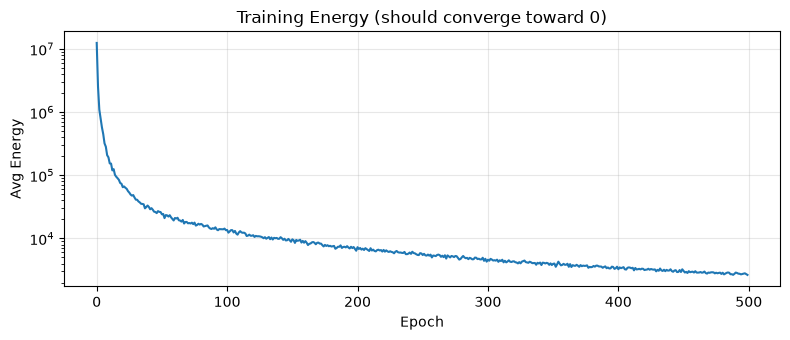

Final energy: 2650.179932


In [28]:
avg_energy = [sum(e) / len(e) if e else 0 for e in energy_history]
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(avg_energy)
ax.set_xlabel("Epoch")
ax.set_ylabel("Avg Energy")
ax.set_title("Training Energy (should converge toward 0)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Final energy: {avg_energy[-1]:.6f}")

### 1.3 Denoising retrieval

Corrupt the stored images with Gaussian noise and retrieve the originals via the iterative function *F*.

In [29]:
corrupted = add_gaussian_noise(images, variance=NOISE_VARIANCE, seed=SEED)

t0 = time.time()
denoised = retrieve_from_corruption(
    params, structure, corrupted,
    num_iterations=RETRIEVAL_ITERS,
    retrieval_infer_steps=RETRIEVAL_INFER_STEPS,
    seed=SEED,
)
print(f"Retrieval time: {time.time() - t0:.1f}s")

m = retrieval_metrics(images, denoised, threshold=0.005)
noise_mse = float(np.mean((images - corrupted) ** 2))
print(f"Noise MSE:      {noise_mse:.6f}")
print(f"Retrieved MSE:  {m['mean_mse']:.6f}  (max: {m['max_mse']:.6f})")
print(f"Accuracy (MSE < 0.005): {m['accuracy']*100:.1f}%")

Retrieval time: 29.4s
Noise MSE:      0.201576
Retrieved MSE:  nan  (max: nan)
Accuracy (MSE < 0.005): 0.0%


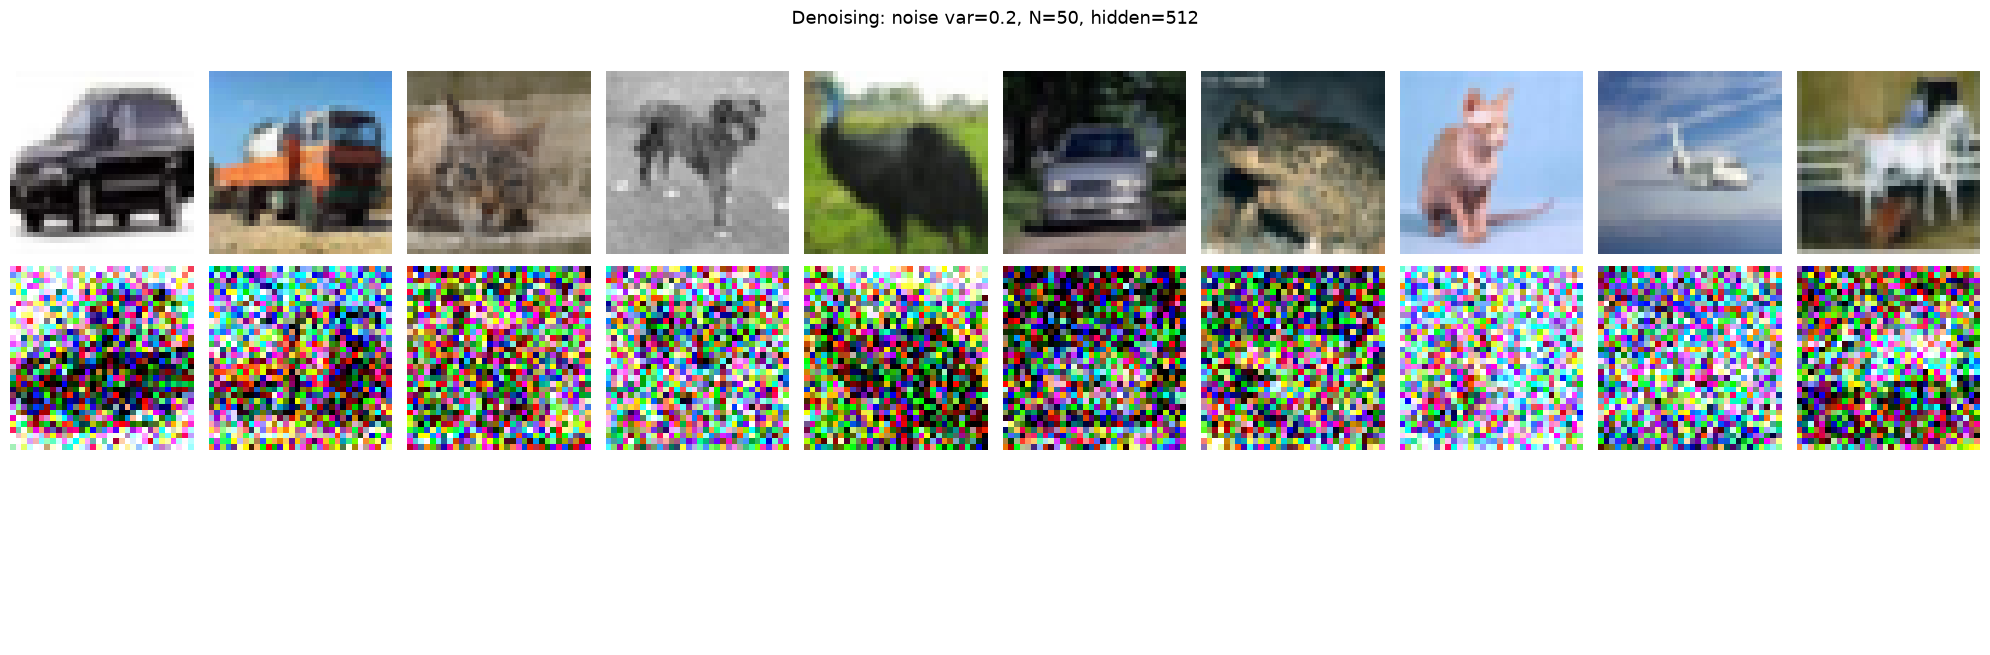

In [30]:
show_reconstruction_grid(images, corrupted, denoised,
                         title=f"Denoising: noise var={NOISE_VARIANCE}, "
                               f"N={N_IMAGES}, hidden={HIDDEN_DIM}")

---

## Experiment 2 &mdash; Partial Image Retrieval (Section 4)

**Protocol:** Present only a fraction of pixels (1/2, 1/4) from each stored image. Unknown pixels evolve freely during inference while known pixels are pinned after each step.

- Retrieval accuracy threshold: MSE < 0.001


--- Fraction = 0.5 (known pixels: 1534/3072) ---
Retrieval time: 1.6s
Mean MSE:  0.141383  (max: 0.319496)
Accuracy (MSE < 0.001): 0.0%


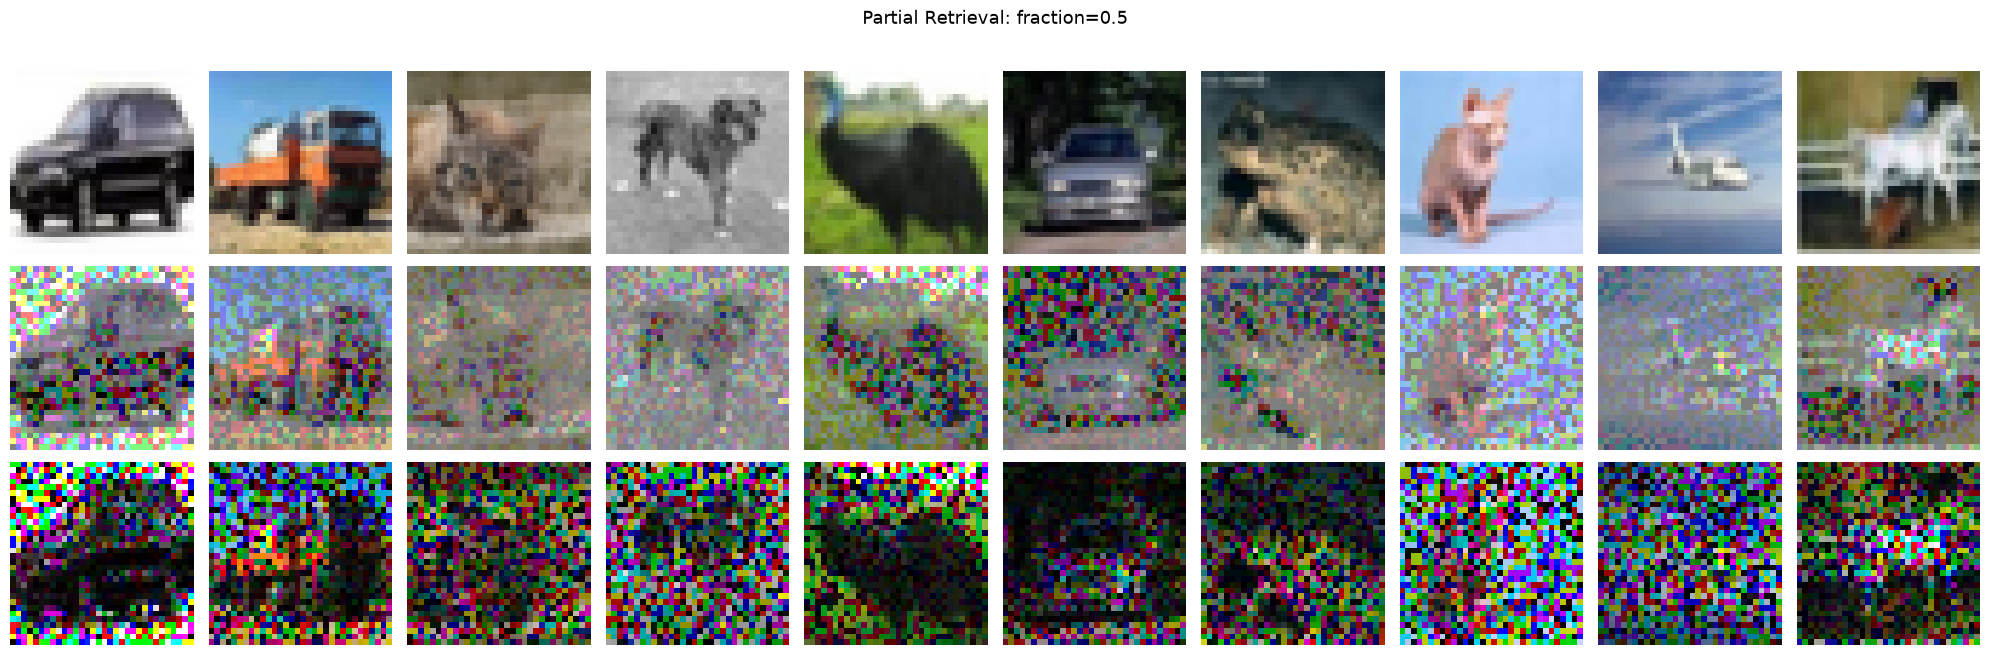


--- Fraction = 0.25 (known pixels: 768/3072) ---
Retrieval time: 1.6s
Mean MSE:  0.212371  (max: 0.472901)
Accuracy (MSE < 0.001): 0.0%


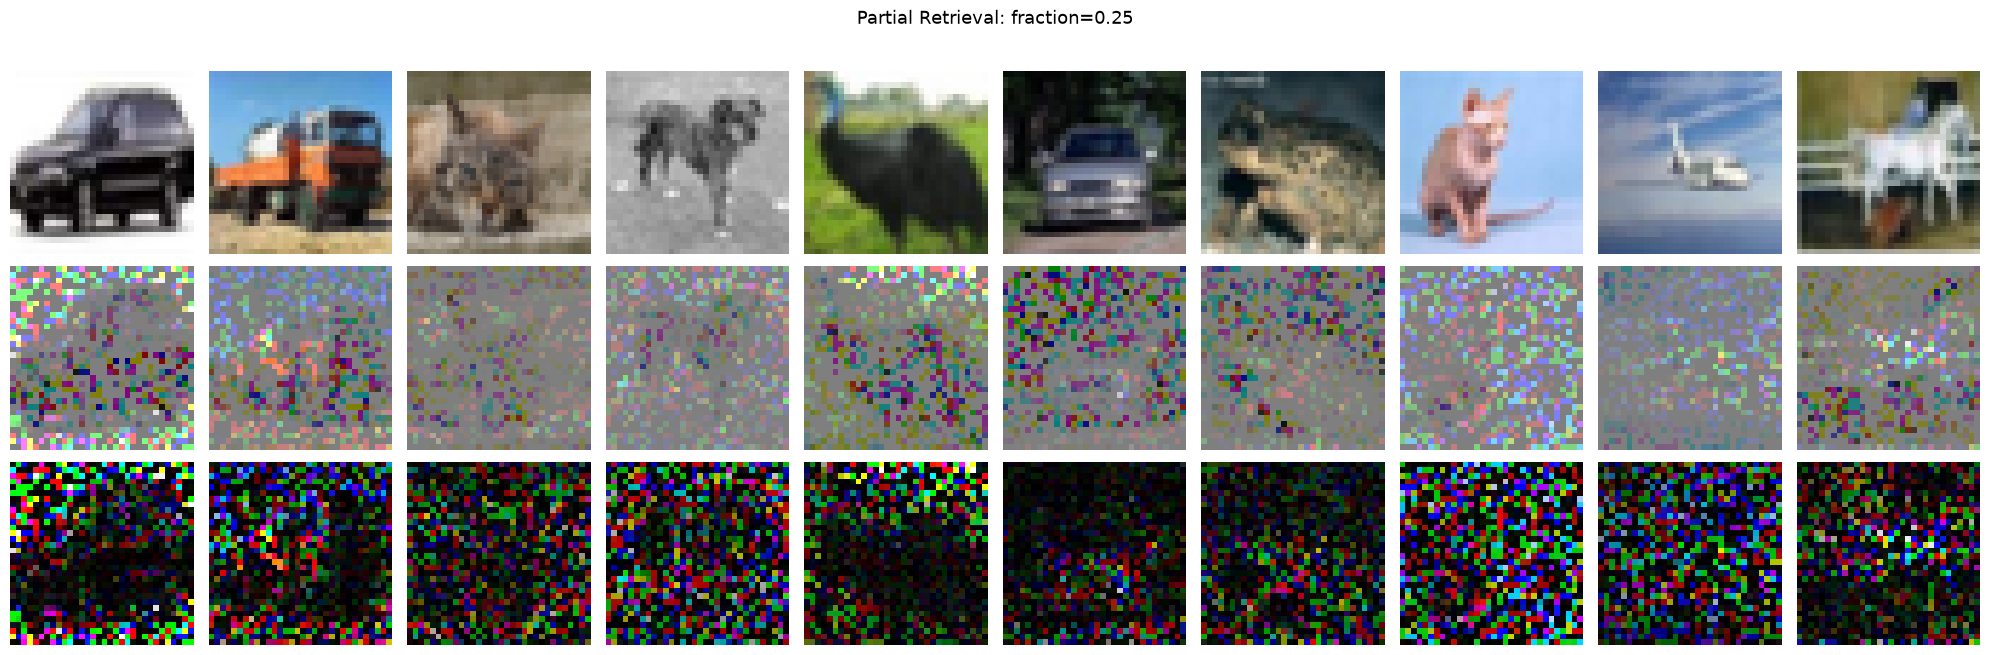

In [31]:
PARTIAL_INFER_STEPS = 500   # more steps for partial retrieval
data_dim = images.shape[1]

for frac in [0.5, 0.25]:
    mask = generate_pixel_mask(N_IMAGES, data_dim, frac, seed=SEED)
    print(f"\n--- Fraction = {frac} (known pixels: {mask.sum(axis=1).mean():.0f}/{data_dim}) ---")

    t0 = time.time()
    partial_retrieved = retrieve_from_partial(
        params, structure, images, mask,
        infer_steps=PARTIAL_INFER_STEPS, seed=SEED,
    )
    print(f"Retrieval time: {time.time() - t0:.1f}s")

    m = retrieval_metrics(images, partial_retrieved, threshold=0.001)
    print(f"Mean MSE:  {m['mean_mse']:.6f}  (max: {m['max_mse']:.6f})")
    print(f"Accuracy (MSE < 0.001): {m['accuracy']*100:.1f}%")

    # Visualise: grey out missing pixels in the input
    partial_vis = np.where(mask, images, 0.5)
    show_reconstruction_grid(images, partial_vis, partial_retrieved,
                              title=f"Partial Retrieval: fraction={frac}")

---

## Experiment 3 &mdash; Deep PCNs (Section 5.1)

**Protocol:** Increase the number of hidden layers while keeping `hidden_dim` fixed. Deeper networks should form richer attractors, improving retrieval on larger datasets.

We re-train a new model for each depth and evaluate partial retrieval.

In [ ]:
# ---- Deep PCN hyperparameters ----
DEEP_N_IMAGES  = 200
DEEP_HIDDEN    = 1024
DEEP_DEPTHS    = [1, 3, 5]       # number of hidden layers
DEEP_EPOCHS    = 2000
DEEP_LR        = 5e-4
DEEP_INFER     = 24
DEEP_ETA       = 0.1
DEEP_FRACTIONS = [0.5, 0.25]
DEEP_RET_STEPS = 500

In [33]:
deep_images = load_cifar10_subset(DEEP_N_IMAGES, seed=SEED)
deep_data_dim = deep_images.shape[1]
print(f"Loaded {DEEP_N_IMAGES} CIFAR-10 images for deep PCN experiment\n")

results = {}

for depth in DEEP_DEPTHS:
    print(f"{'='*55}")
    print(f"  Depth = {depth} hidden layer(s)")
    print(f"{'='*55}")

    t0 = time.time()
    dp, ds, dh = train_generative_pcn(
        deep_images, hidden_dim=DEEP_HIDDEN, num_hidden_layers=depth,
        num_epochs=DEEP_EPOCHS, lr=DEEP_LR, infer_steps=DEEP_INFER,
        eta_infer=DEEP_ETA, seed=SEED,
    )
    print(f"  Training time: {time.time() - t0:.1f}s")

    for frac in DEEP_FRACTIONS:
        mask = generate_pixel_mask(DEEP_N_IMAGES, deep_data_dim, frac, seed=SEED)

        t0 = time.time()
        ret = retrieve_from_partial(dp, ds, deep_images, mask,
                                    infer_steps=DEEP_RET_STEPS, seed=SEED)
        m = retrieval_metrics(deep_images, ret, threshold=0.001)
        results[(depth, frac)] = m
        print(f"  frac={frac}  MSE={m['mean_mse']:.6f}  "
              f"acc={m['accuracy']*100:.1f}%  ({time.time()-t0:.1f}s)")
    print()

Loaded 200 CIFAR-10 images for deep PCN experiment

  Depth = 1 hidden layer(s)
Architecture: memory(1024) -> hidden_0(1024) -> sensory(3072)
Parameters:   4,198,400
Training on 1 device(s): [CudaDevice(id=0)]


W0000 00:00:1788470754.592689     113 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


  0%|          | 0/500 [00:00<?, ?it/s]

  Training time: 11.4s
  frac=0.5  MSE=0.140843  acc=0.0%  (1.6s)
  frac=0.25  MSE=0.211616  acc=0.0%  (1.6s)

  Depth = 3 hidden layer(s)
Architecture: memory(1024) -> hidden_0(1024) -> hidden_1(1024) -> hidden_2(1024) -> sensory(3072)
Parameters:   6,297,600
Training on 1 device(s): [CudaDevice(id=0)]


  0%|          | 0/500 [00:00<?, ?it/s]

  Training time: 14.8s
  frac=0.5  MSE=0.039608  acc=0.0%  (1.8s)
  frac=0.25  MSE=0.059394  acc=0.0%  (1.8s)

  Depth = 5 hidden layer(s)
Architecture: memory(1024) -> hidden_0(1024) -> hidden_1(1024) -> hidden_2(1024) -> hidden_3(1024) -> hidden_4(1024) -> sensory(3072)
Parameters:   8,396,800
Training on 1 device(s): [CudaDevice(id=0)]


  0%|          | 0/500 [00:00<?, ?it/s]

  Training time: 17.7s
  frac=0.5  MSE=0.035227  acc=0.0%  (1.9s)
  frac=0.25  MSE=0.052924  acc=0.0%  (1.9s)



### Summary plot &mdash; depth vs. retrieval MSE

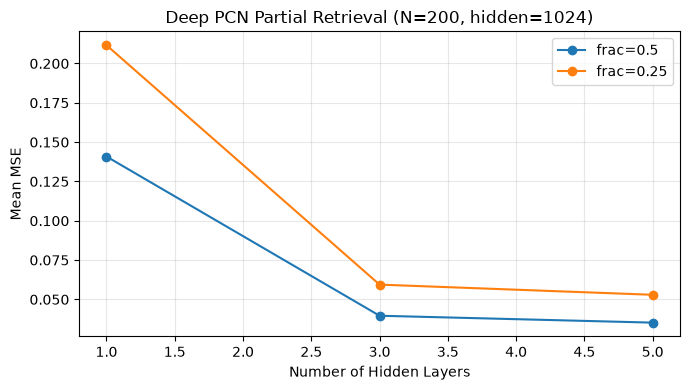

In [34]:
fig, ax = plt.subplots(figsize=(7, 4))
for frac in DEEP_FRACTIONS:
    mses = [results[(d, frac)]["mean_mse"] for d in DEEP_DEPTHS]
    ax.plot(DEEP_DEPTHS, mses, "o-", label=f"frac={frac}")
ax.set_xlabel("Number of Hidden Layers")
ax.set_ylabel("Mean MSE")
ax.set_title(f"Deep PCN Partial Retrieval (N={DEEP_N_IMAGES}, hidden={DEEP_HIDDEN})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Notes

- **Convergence**: The paper trains "until convergence" (energy near zero). If results are poor, increase `NUM_EPOCHS` or adjust `LR`/`ETA_INFER`.
- **GPU acceleration**: These experiments benefit significantly from GPU. Set `JAX_PLATFORMS=cuda` if a GPU is available.
- **Activation placement**: FabricPC applies activations post-synaptically (`z_mu = f(W@x + b)`) while the paper applies them pre-synaptically (`mu = W @ f(x)`). Results are qualitatively similar but not numerically identical. A custom `NodeBase` subclass with pre-synaptic activation can be substituted for exact replication.
- **Hetero-associative memory** (Section 7 of the paper) is not covered here but can be implemented by concatenating image and text token vectors as the sensory input.